In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df_2024_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal= ',')
df_2024_2 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2024.02.csv', sep=';', decimal= ',')
df_2025_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal= ',')
df_2025_2 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.02.csv', sep=';', decimal= ',')

C:\Users\carlos.orodrigues\AppData\Local\Temp\ipykernel_2812\1461245115.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal= ',')


In [43]:
df = pd.concat([df_2024_1, df_2024_2, df_2025_1, df_2025_2], ignore_index=True)
print (df.shape) 
display (df.head())

(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1712267 entries, 0 to 1712266
Data columns (total 16 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Regiao - Sigla     str    
 1   Estado - Sigla     str    
 2   Municipio          str    
 3   Revenda            str    
 4   CNPJ da Revenda    object 
 5   Nome da Rua        str    
 6   Numero Rua         str    
 7   Complemento        str    
 8   Bairro             str    
 9   Cep                str    
 10  Produto            str    
 11  Data da Coleta     str    
 12  Valor de Venda     float64
 13  Valor de Compra    float64
 14  Unidade de Medida  str    
 15  Bandeira           str    
dtypes: float64(2), object(1), str(13)
memory usage: 209.0+ MB


In [45]:
print(df.columns)

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='str')


In [46]:
TESTE = df ['Municipio'].value_counts().reset_index() #para verificar o que há dentro da coluna, nesse caso produto
TESTE

,Municipio,count
0,SAO PAULO,80021
1,RIO DE JANEIRO,34045
2,FORTALEZA,18010
3,BRASILIA,16631
4,CURITIBA,16500
...,...,...
456,CAMETA,223
457,SAPUCAIA,204
458,VERA CRUZ,63
459,GAVIAO,55


In [47]:
df.tail(3)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
1712264,NE,BA,ILHEUS,BATISTA COMERCIO DE COMBUSTIVEIS E LUBRIFICANT...,28562491000183,AVENIDA FERROVIARIA,S/N,KM 05 RODOVIA ILHEUS,IGUAPE,45658-340,GNV,31/12/2025,4.73,NaN,R$ / m3,BRANCA
1712265,SE,SP,JACAREI,AUTO POSTO BRANCO DE CASTELO LTDA,68912864000385,AVENIDA SIQUEIRA CAMPOS,641,NaN,CENTRO,12308-190,GNV,31/12/2025,3.99,NaN,R$ / m3,VIBRA
1712266,S,RS,LAJEADO,SIM REDE DE POSTOS LTDA,7473735018714,RODOVIA ERS-130,2285,KM 72.8,SANTO ANDRE,95912-000,GNV,31/12/2025,5.65,NaN,R$ / m3,CHARRUA


In [ ]:
#1. filtro com loc para achar somente o que preciso, no caso só gasolina no estado do RJ
df_gasolina = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]
df_gasolina


In [ ]:
#outra forma de filtro com loc, mais usado quando preciso de mais elementos dentro do filtro
df_prod = ['GASOLINA']#cria a lista

df_rj = df.loc[df['Produto'].isin(df_prod) & (df['Estado - Sigla'] == 'RJ')]#faz o isin pra puxar o que há dentro da lista que está como variável df_prod
df_rj

In [ ]:
#2 média de preço dos municípios do RJ
df_gasolina_comum_rj = df_gasolina.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_comum_rj

In [72]:
#coluna 'Data da Coleta' está em string, aqui converto para float, para usar no gráfico, fazendo dados de data da coleta assumir questão temporal
df_gasolina['Data da Coleta'] = pd.to_datetime(df_gasolina['Data da Coleta'], dayfirst=True)


In [ ]:

df_gasosa_tempo = df_gasolina.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Data da Coleta')
df_gasosa_tempo

<function matplotlib.pyplot.show(close=None, block=None)>

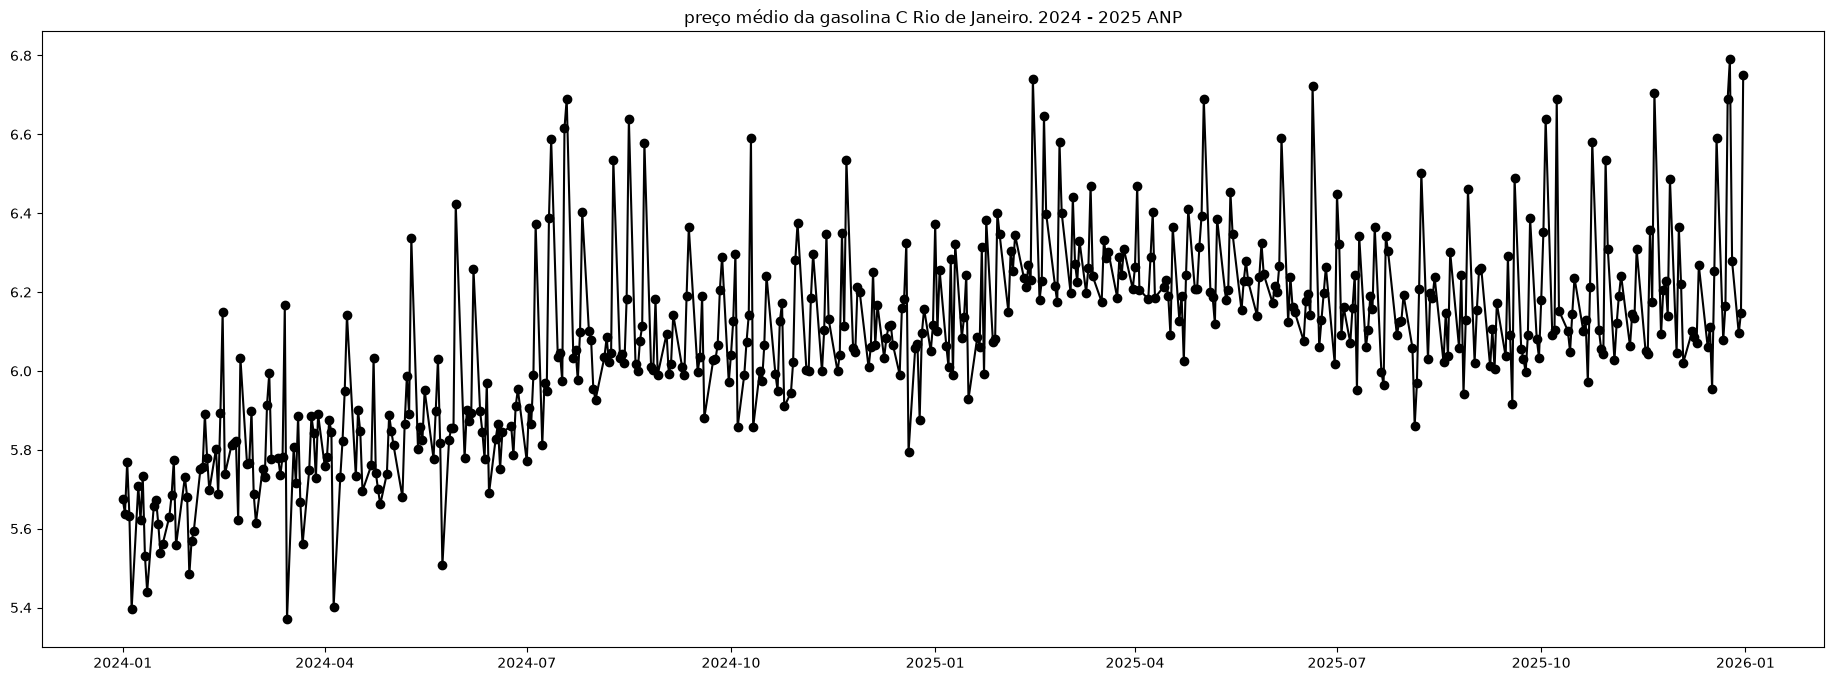

In [93]:
plt.figure(figsize=(23,8))
plt.plot(df_gasosa_tempo['Data da Coleta'], df_gasosa_tempo['Valor de Venda'], marker = 'o', color='black')
plt.title('preço médio da gasolina C Rio de Janeiro. 2024 - 2025 ANP')
plt.show

In [ ]:
df_gasolina_comum_rj_posto = df_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_comum_rj_posto

In [ ]:
array_gas_comum_rj = np.array(df_gasolina_comum_rj_posto['Valor de Venda'])
array_gas_comum_rj

In [ ]:
media = np.mean(array_gas_comum_rj)
mediana = np.median(array_gas_comum_rj)
q1 = np.percentile(array_gas_comum_rj, 25)
q3 = np.percentile(array_gas_comum_rj,75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
distancia = (media - mediana) / mediana

print (f'Média {media}')
print (f'Mediana {mediana}')
print (f'Distancia {distancia:.2%}')
print (f'Q1 {q1}')
print (f'Q3 {q3}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')


Média 5.947818265606212
Mediana 5.9136419461502125
Distancia 0.58%
Q1 5.692154135338346
Q3 6.19
Limite Superior 6.936768796992482
Limite Inferior 4.945385338345865


In [ ]:
outlier_sup_preco = df_gasolina_comum_rj_posto.loc[df_gasolina_comum_rj_posto['Valor de Venda'] > limite_superior]

outlier_sup_preco

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000


In [ ]:
outlier_inf_preco = df_gasolina_comum_rj_posto.loc[df_gasolina_comum_rj_posto['Valor de Venda'] < limite_inferior]

outlier_inf_preco

,Revenda,Valor de Venda


In [ ]:
df_est = ['RJ','SP']
df_eta = df.loc[df['Estado - Sigla'].isin(df_est) & (df['Produto'] == 'ETANOL')]
df_eta

In [ ]:
df_RJ_etanol = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'ETANOL')]
df_RJ_etanol

In [ ]:
df_etanol_rj = df_RJ_etanol.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_rj

In [ ]:
array_etanol_rj = np.array(df_etanol_rj['Valor de Venda'])
array_etanol_rj

In [ ]:
media_rj = np.mean(array_etanol_rj)
mediana_rj = np.median(array_etanol_rj)
q1_rj = np.percentile(array_etanol_rj, 25)
q3_rj = np.percentile(array_etanol_rj,75)
iqr = q3_rj - q1_rj
limite_superior_rj = q3_rj + (1.5 * iqr)
limite_inferior_rj = q1_rj - (1.5 * iqr)
distancia = (media_rj - mediana_rj) / mediana_rj

print (f'Média {media_rj}')
print (f'Mediana {mediana_rj}')
print (f'Distancia {distancia:.2%}')
print (f'Q1 {q1_rj}')
print (f'Q3 {q3_rj}')
print(f'Limite Superior {limite_superior_rj}')
print(f'Limite Inferior {limite_inferior_rj}')

Média 4.446460031915704
Mediana 4.407249773866983
Distancia 0.89%
Q1 4.27764986189478
Q3 4.558372256933862
Limite Superior 4.979455849492485
Limite Inferior 3.8565662693361564


In [ ]:
df_SP_etanol = df.loc[(df['Estado - Sigla'] == 'SP') & (df['Produto'] == 'ETANOL')]
df_SP_etanol

In [ ]:
df_etanol_sp = df_SP_etanol.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_sp

In [ ]:
array_etanol_sp = np.array(df_etanol_sp['Valor de Venda'])
array_etanol_sp

In [ ]:
media_sp = np.mean(array_etanol_sp)
mediana_sp = np.median(array_etanol_sp)
q1_sp = np.percentile(array_etanol_sp, 25)
q3_sp = np.percentile(array_etanol_sp,75)
iqr = q3_sp - q1_sp
limite_superior_sp = q3_sp + (1.5 * iqr)
limite_inferior_sp = q1_sp - (1.5 * iqr)
distancia_sp = (media_sp - mediana_sp) / mediana_sp

print (f'Média SP {media_sp}')
print (f'Mediana SP {mediana_sp}')
print (f'Distancia {distancia_sp:.2%}')
print (f'Q1 {q1_sp}')
print (f'Q3 {q3_sp}')
print(f'Limite Superior {limite_superior_sp}')
print(f'Limite Inferior {limite_inferior_sp}')

Média SP 3.857237583625291
Mediana SP 3.8796232395121337
Distancia -0.58%
Q1 3.7518841150359172
Q3 3.9669126446587217
Limite Superior 4.2894554390929285
Limite Inferior 3.4293413206017105


In [ ]:

print (f'Média do etanol RJ {media_rj}\nMédia do etanol SP {media_sp}')

print(f'Maior preço RJ\n {df_etanol_rj.max()}')
print(f'Menor preço RJ\n {df_etanol_rj.min()}')

print(f'Maior preço SP\n {df_etanol_sp.max()}')
print(f'Menor preço SP\n {df_etanol_sp.min()}')


Média do etanol RJ 4.446460031915704
Média do etanol SP 3.857237583625291
Maior preço RJ
 Municipio         VOLTA REDONDA
Valor de Venda         5.128235
dtype: object
Menor preço RJ
 Municipio         ANGRA DOS REIS
Valor de Venda          3.816982
dtype: object
Maior preço SP
 Municipio         VOTUPORANGA
Valor de Venda       4.437937
dtype: object
Menor preço SP
 Municipio         ADAMANTINA
Valor de Venda      3.182949
dtype: object


In [ ]:
outlier_sup_preco_rj_eta = df_etanol_rj.loc[df_etanol_rj['Valor de Venda'] > limite_superior_rj]

outlier_sup_preco_rj_eta

,Municipio,Valor de Venda
29,TRES RIOS,5.128235
18,PETROPOLIS,5.062155
0,ANGRA DOS REIS,5.005747


In [ ]:
outlier_inf_preco_rj_eta = df_etanol_rj.loc[df_etanol_rj['Valor de Venda'] < limite_inferior_rj]

outlier_inf_preco_rj_eta

,Municipio,Valor de Venda
28,TERESOPOLIS,3.816982


In [ ]:
outlier_sup_preco_sp_eta = df_etanol_sp.loc[df_etanol_sp['Valor de Venda'] > limite_superior_sp]

outlier_sup_preco_sp_eta

,Municipio,Valor de Venda
10,BARUERI,4.437937
24,CUBATAO,4.394575
31,GUARUJA,4.329950


In [ ]:
outlier_inf_preco_sp_eta = df_etanol_sp.loc[df_etanol_sp['Valor de Venda'] < limite_inferior_sp]

outlier_inf_preco_sp_eta

,Municipio,Valor de Venda
26,DRACENA,3.420116
92,SAO ROQUE,3.396087
81,SANTA BARBARA D'OESTE,3.373045
58,MIRASSOL,3.194895
76,PRESIDENTE VENCESLAU,3.182949


In [ ]:
df_gasosa = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]
df_gasosa

In [140]:
df_gasolina_bairro_rj = df_gasosa.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_bairro_rj

,Bairro,Valor de Venda
23,FLAMENGO,6.696667
41,JARDIM BOTANICO,6.614615
44,LAGOA,6.505385
55,PARQUE FLAMENGO,6.454706
21,ESTACIO,6.416882
...,...,...
50,MEIER,5.340000
37,JACARE,5.310000
49,MARIA DA GRACA,5.290000
43,JARDIM SULACAP,5.226364


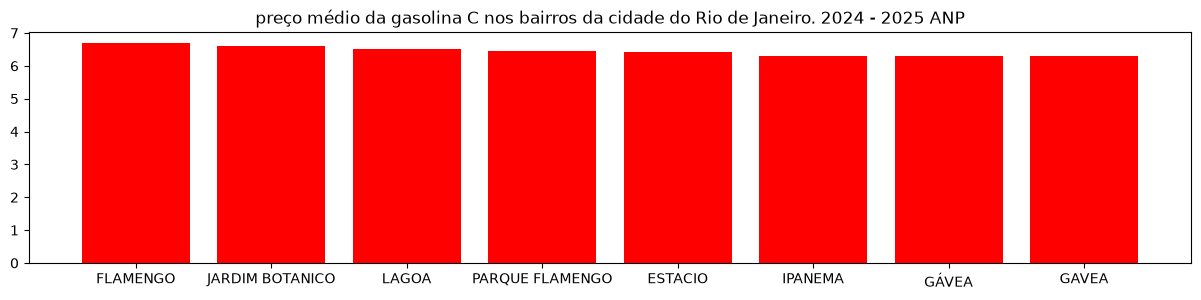

In [163]:
plt.figure(figsize=(15,3))
plt.bar(df_gasolina_bairro_rj.head(8)['Bairro'], df_gasolina_bairro_rj.head(8)['Valor de Venda'], color='red')
plt.title('preço médio da gasolina C nos bairros da cidade do Rio de Janeiro. 2024 - 2025 ANP')
plt.show()

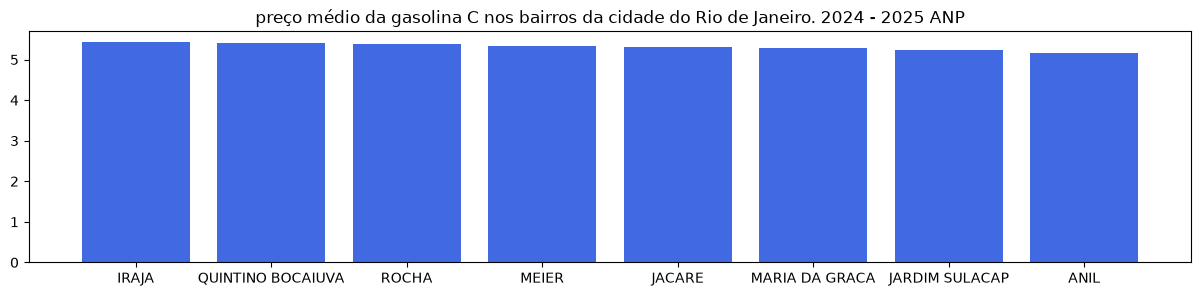

In [164]:
plt.figure(figsize=(15,3))
plt.bar(df_gasolina_bairro_rj.tail(8)['Bairro'], df_gasolina_bairro_rj.tail(8)['Valor de Venda'], color='#4169E1')
plt.title('preço médio da gasolina C nos bairros da cidade do Rio de Janeiro. 2024 - 2025 ANP')
plt.show()

In [ ]:
array_bairro = np.array(df_gasolina_bairro_rj['Valor de Venda'])
array_bairro



In [95]:
minimo = np.min(array_bairro)
maximo = np.max(array_bairro)
amplitude = maximo - minimo
media_br = np.mean (array_bairro)
mediana_br = np.median (array_bairro)
q1_br = np.percentile(array_bairro, 25)
q3_br = np.percentile(array_bairro,75)
iqr_br = q3_br - q1_br
limite_superior_br = q3_br + (1.5 * iqr_br)
limite_inferior_br = q1_br - (1.5 * iqr_br)
distancia_br = (media_br - mediana_br) / mediana_br

print (f'Mínimo {minimo}')
print (f'Máximo {maximo}')
print (f'Amplitude {amplitude}')
print (f'Média {media_br}')
print (f'Mediana {mediana_br}')
print (f'Distancia {distancia_br:.2%}')
print (f'Q1 {q1_br}')
print (f'Q3 {q3_br}')
print(f'Limite Superior {limite_superior_br}')
print(f'Limite Inferior {limite_inferior_br}')

Mínimo 5.156666666666666
Máximo 6.696666666666667
Amplitude 1.540000000000001
Média 5.854678797322661
Mediana 5.8434
Distancia 0.19%
Q1 5.640000000000001
Q3 6.060588235294118
Limite Superior 6.691470588235293
Limite Inferior 5.009117647058825


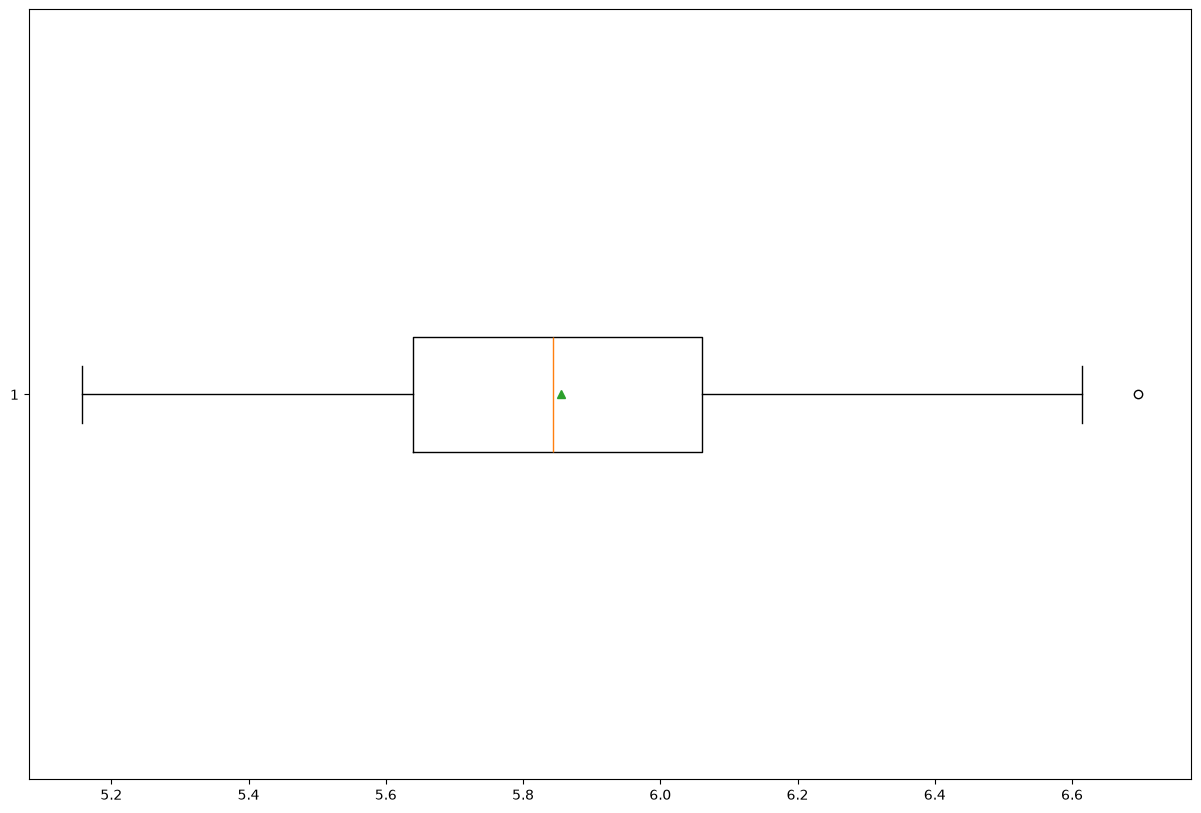

In [155]:
plt.figure(figsize=(15,10))
plt.boxplot(array_bairro, orientation='horizontal', showmeans=True)
plt.show()

In [128]:
outlier_sup_bairro = df_gasolina_bairro_rj.loc[df_gasolina_bairro_rj['Valor de Venda'] > limite_superior_br]
outlier_sup_bairro

,Bairro,Valor de Venda
23,FLAMENGO,6.696667


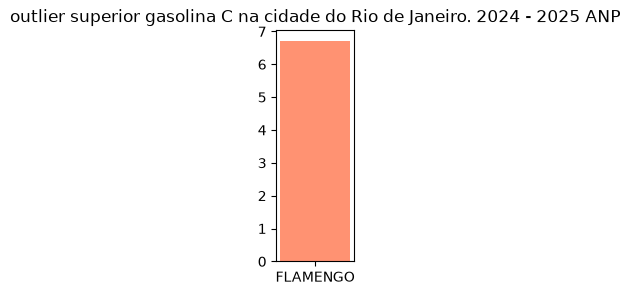

In [161]:
plt.figure(figsize=(1,3))
plt.bar(outlier_sup_bairro['Bairro'], outlier_sup_bairro['Valor de Venda'], color='#FF9272')
plt.title('outlier superior gasolina C na cidade do Rio de Janeiro. 2024 - 2025 ANP')
plt.show()



In [ ]:
outlier_inf_bairro = df_gasolina_bairro_rj.loc[df_gasolina_bairro_rj['Valor de Venda'] < limite_inferior_br]
outlier_inf_bairro

,Bairro,Valor de Venda


In [170]:
df_gasosa_fla = df.loc[(df['Bairro'] == 'FLAMENGO') & (df['Produto'] == 'GASOLINA')]
df_gasosa_fla

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
8383,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,03/01/2024,6.49,NaN,R$ / litro,VIBRA
48150,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,17/01/2024,6.49,NaN,R$ / litro,VIBRA
153918,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,27/02/2024,6.49,NaN,R$ / litro,VIBRA
231633,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,27/03/2024,6.49,NaN,R$ / litro,VIBRA
246461,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,02/04/2024,6.49,NaN,R$ / litro,VIBRA
321764,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,30/04/2024,6.49,NaN,R$ / litro,VIBRA
356849,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,14/05/2024,6.49,NaN,R$ / litro,VIBRA
391124,SE,RJ,MARICA,AUTO POSTO MARGUI II LTDA,31.678.086/0001-30,AVENIDA ROBERTO DA SILVEIRA,2136,COB. BOMBAS QUADRA00 ...,FLAMENGO,24903-815,GASOLINA,27/05/2024,5.99,NaN,R$ / litro,ALE
392436,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,28/05/2024,6.49,NaN,R$ / litro,VIBRA
411404,SE,RJ,RIO DE JANEIRO,AUTO POSTO ATERRO DO FLAMENGO LTDA,01.309.199/0001-05,AVENIDA INFANTO DOM HENRIQUE,S/N,NaN,FLAMENGO,20021-140,GASOLINA,04/06/2024,6.49,NaN,R$ / litro,VIBRA


In [169]:
df_gasosa_fla['Data da Coleta'] = pd.to_datetime(df_gasosa_fla['Data da Coleta'], dayfirst=True)

In [ ]:
df_gasosa_flamengo = df_gasosa_fla.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Data da Coleta')
df_gasosa_flamengo

<function matplotlib.pyplot.show(close=None, block=None)>

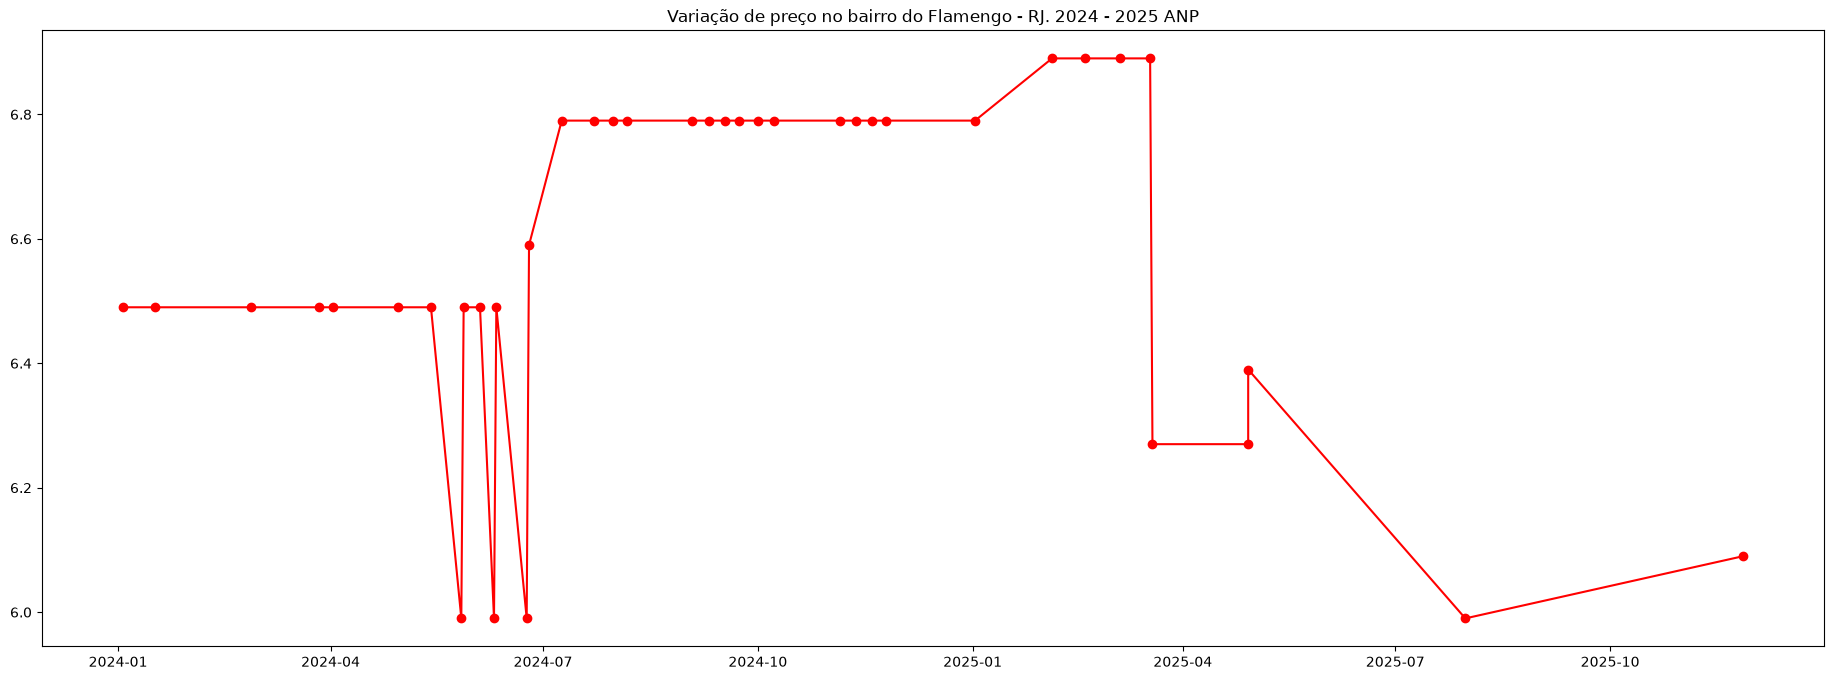

In [151]:
plt.figure(figsize=(23,8))
plt.plot(df_gasosa_fla['Data da Coleta'], df_gasosa_fla['Valor de Venda'], marker = 'o', color='red')
plt.title('Variação de preço no bairro do Flamengo - RJ. 2024 - 2025 ANP')
plt.show